In [ ]:
!pip install --quiet -r requirements.txt

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
DATA_PREPR = Path("./data-sources/pre-processed")
DATA_RAW = Path("./data-sources/raw")

In [21]:
def convertir_txt_data_frame(ruta_path):
    txt_files = list(ruta_path.glob("*.txt"))
    data = []
    for path in txt_files:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            data.append({"text": content})

    df = pd.DataFrame(data)
    return df

In [22]:
temp_cochrane_train_non_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/train/non_pls')
temp_cochrane_train_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/train/pls')
temp_cochrane_test_non_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/test/non_pls')
temp_cochrane_test_pls = convertir_txt_data_frame(DATA_RAW/'cochrane/test/pls')
print(f'Archivos leidos cochrane train non-pls {len(temp_cochrane_train_non_pls)}')
print(f'Archivos leidos cochrane train pls {len(temp_cochrane_train_pls)}')
print(f'Archivos leidos cochrane test non-pls {len(temp_cochrane_test_non_pls)}')
print(f'Archivos leidos cochrane test pls {len(temp_cochrane_test_pls)}')
temp_cochrane_train_non_pls['pls'] = 0
temp_cochrane_train_pls['pls'] = 1
temp_cochrane_test_non_pls['pls'] = 0
temp_cochrane_test_pls['pls'] = 1

Archivos leidos cochrane train non-pls 31118
Archivos leidos cochrane train pls 16241
Archivos leidos cochrane test non-pls 7664
Archivos leidos cochrane test pls 3940


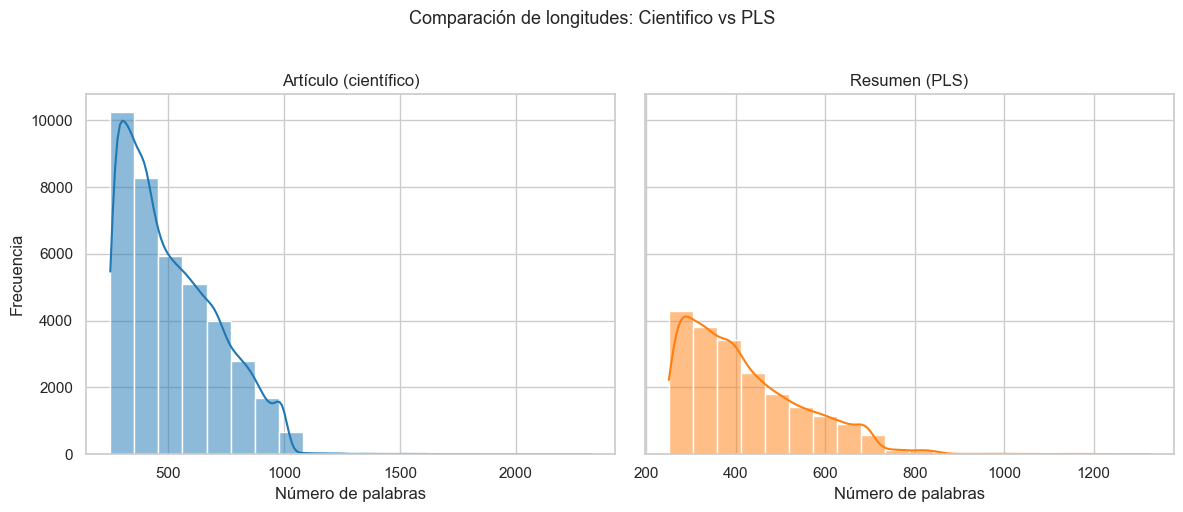

In [29]:
df_temp_cientific = pd.concat([temp_cochrane_train_non_pls['text'],temp_cochrane_test_non_pls['text']],ignore_index=True)
df_temp_pls = pd.concat([temp_cochrane_train_pls['text'],temp_cochrane_test_pls['text']],ignore_index=True)

len_article_words = df_temp_cientific.astype(str).apply(lambda x: len(x.split()))
len_summary_words = df_temp_pls.astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(len_article_words, bins=20, color="tab:blue", ax=axes[0], kde=True)
axes[0].set_title("Artículo (científico)")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")

sns.histplot(len_summary_words, bins=20, color="tab:orange", ax=axes[1], kde=True)
axes[1].set_title("Resumen (PLS)")
axes[1].set_xlabel("Número de palabras")

plt.suptitle("Comparación de longitudes: Cientifico vs PLS", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
df_csv = pd.concat([temp_cochrane_train_non_pls,temp_cochrane_train_pls,temp_cochrane_test_non_pls,temp_cochrane_test_pls],ignore_index=True)
rows_per_chunk = 15000
for i, start in enumerate(range(0, len(df_csv), rows_per_chunk), start=1):
    ##Se guarda el dato en bloques para que el archivo resultante sea inferior a 100MB y pueda subirse sin problemas a Github
    df_csv.iloc[start:start+rows_per_chunk].to_csv(f"{DATA_PREPR}/data_chunk_{i}.csv", index=False)